# Proyecto de Clasificación Multiclase: Predicción de Sistemas Operativos (Usuarios Win / Mac / Lin)

## Objetivo del Proyecto

El objetivo principal de este proyecto es analizar el comportamiento de navegación de los usuarios en una plataforma web y construir un modelo de **Regresión Logística Multiclase** capaz de predecir el sistema operativo que utiliza cada usuario (`clase`).

A través de este modelo se busca:
1. **Comprender la relación** entre el comportamiento en el sitio (`duracion`, `paginas`, `acciones`, `valor`) y la pertenencia a una clase de sistema operativo específica (`0`, `1` o `2`).
2. **Evaluar la asimetría y la presencia de outliers** mediante visualizaciones combinadas (histogramas y *boxplots*) para fundamentar el preprocesamiento de datos.
3. **Tratar activamente la desigualdad de clases** detectada en la muestra original para evitar que el modelo favorezca únicamente a la clase mayoritaria.
4. **Evaluar el rendimiento predictivo** en un conjunto de datos no visto mediante métricas estándar de clasificación (Precisión, Recall, F1-Score, Matriz de Confusión).
5. **Ofrecer insights de negocio** basados en la interpretación de los coeficientes (Odds Ratios) para la toma de decisiones.

## Importación de Librerías

Cargamos las librerías necesarias para el análisis exploratorio, preprocesamiento, tratamiento de desbalance y modelado.

In [84]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Estilo gráfico consistente
sns.set_theme(style="whitegrid")

## Carga y Exploración Inicial del Dataset

Cargamos el dataset `usuarios_win_mac_lin.csv` y realizamos una primera inspección estructural.

In [85]:
df = pd.read_csv("../Datos/usuarios_win_mac_lin.csv")
df.head()

,duracion,paginas,acciones,valor,clase
0,7.0,2,4,8,2
1,21.0,2,6,6,2
2,57.0,2,4,4,2
3,101.0,3,6,12,2
4,109.0,2,6,12,2


## Limpieza de Datos y Verificación de Estructura

Revisamos los tipos de datos, datos faltantes y duplicados. En este caso se eliminan los duplicados que son 16.

In [86]:
# Verificación de tipos de datos y nulos
df.info()

# Verificación y tratamiento de duplicados
duplicados = df.duplicated().sum()
print(f"\nRegistros duplicados detectados: {duplicados}")

if duplicados > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Dataset luego de eliminar duplicados: {df.shape[0]} filas.")

<class 'pandas.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   duracion  170 non-null    float64
 1   paginas   170 non-null    int64  
 2   acciones  170 non-null    int64  
 3   valor     170 non-null    int64  
 4   clase     170 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 6.8 KB

Registros duplicados detectados: 16
Dataset luego de eliminar duplicados: 154 filas.


## Análisis Exploratorio de Datos (EDA)

### Estadísticas Descriptivas de las Variables Predictoras
**Nota metodológica:** Aplicamos `.describe()` únicamente a las **variables predictoras continuas/numéricas** (`duracion`, `paginas`, `acciones`, `valor`). **No** incluimos la variable objetivo `clase`, ya que al ser categórica/discreta (`0`, `1`, `2`), métricas como la media o la desviación estándar carecen de significado matemático o analítico válido.

In [87]:
# Selección exclusiva de las variables predictoras continuas
variables_predictoras = ["duracion", "paginas", "acciones", "valor"]
df[variables_predictoras].describe()

,duracion,paginas,acciones,valor
count,154.000000,154.000000,154.000000,154.000000
mean,121.408273,2.149351,9.272727,35.214286
std,210.075635,1.537260,9.414405,46.220269
min,1.000000,1.000000,1.000000,1.000000
25%,11.000000,1.000000,4.000000,12.000000
50%,13.000000,2.000000,6.000000,24.000000
75%,123.000000,2.000000,12.000000,40.000000
max,898.000000,9.000000,63.000000,378.000000


### Análisis de la Variable Objetivo y Desigualdad de Clases

Para analizar la variable objetivo `clase`, utilizamos conteos absolutos y porcentuales en lugar de métricas descriptivas continuas.

**Observación sobre la Desigualdad de Clases:**
Existe un **desbalance de clases significativo**:
* La **Clase 0** representa la mayoría de las observaciones ($\approx 53.9\%$).
* Las **Clases 1 y 2** son minoritarias ($\approx 24.7\%$ y $\approx 21.4\%$ respectivamente).

*Impacto en el modelo:* Un algoritmo entrenado con datos desbalanceados tenderá a predecir con mayor frecuencia la clase mayoritaria para maximizar la exactitud general (*Accuracy*), perjudicando la tasa de acierto en las clases minoritarias.

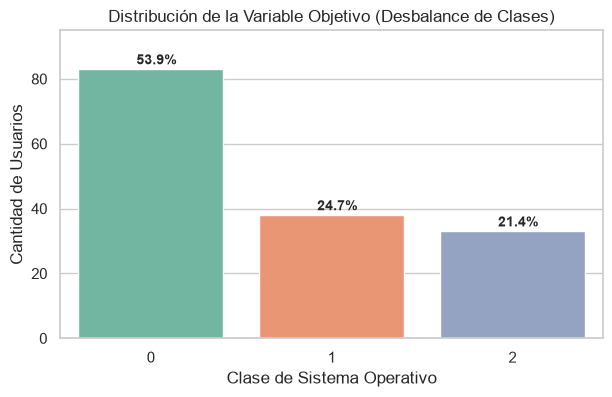

In [88]:
# Conteo absoluto y relativo de la variable objetivo
conteo_clases = df["clase"].value_counts()
porcentajes_clases = df["clase"].value_counts(normalize=True) * 100


# Gráfico de barras para visualizar el desbalance
plt.figure(figsize=(7, 4))
ax = sns.countplot(x="clase", data=df, palette="Set2", hue="clase", legend=False)
plt.title("Distribución de la Variable Objetivo (Desbalance de Clases)")
plt.xlabel("Clase de Sistema Operativo")
plt.ylabel("Cantidad de Usuarios")

# Agregar porcentajes encima de cada barra
total = len(df)
for p in ax.patches:
    percentage = f"{100 * p.get_height() / total:.1f}%"
    x = p.get_x() + p.get_width() / 2 - 0.08
    y = p.get_y() + p.get_height() + 1.5
    ax.annotate(percentage, (x, y), size=10, weight="bold")

plt.ylim(0, max(conteo_clases) + 12)
plt.show()

### Análisis de Distribución, Asimetría y Outliers (Histogramas y Boxplots)

Evaluamos la forma de la distribución (asimetría o *skewness*) y la presencia de valores atípicos mediante la combinación de **Histogramas (con estimación de densidad KDE)** y **Diagramas de Caja (Boxplots)**.

**Relevancia analítica:**
1. **Asimetría:** Permite identificar si los datos se concentran en un extremo o si presentan colas largas a la derecha.
2. **Tratamiento de Outliers:** Evaluamos la presencia de observaciones distantes mediante la regla del Rango Intercuartílico ($1.5 \times IQR$).

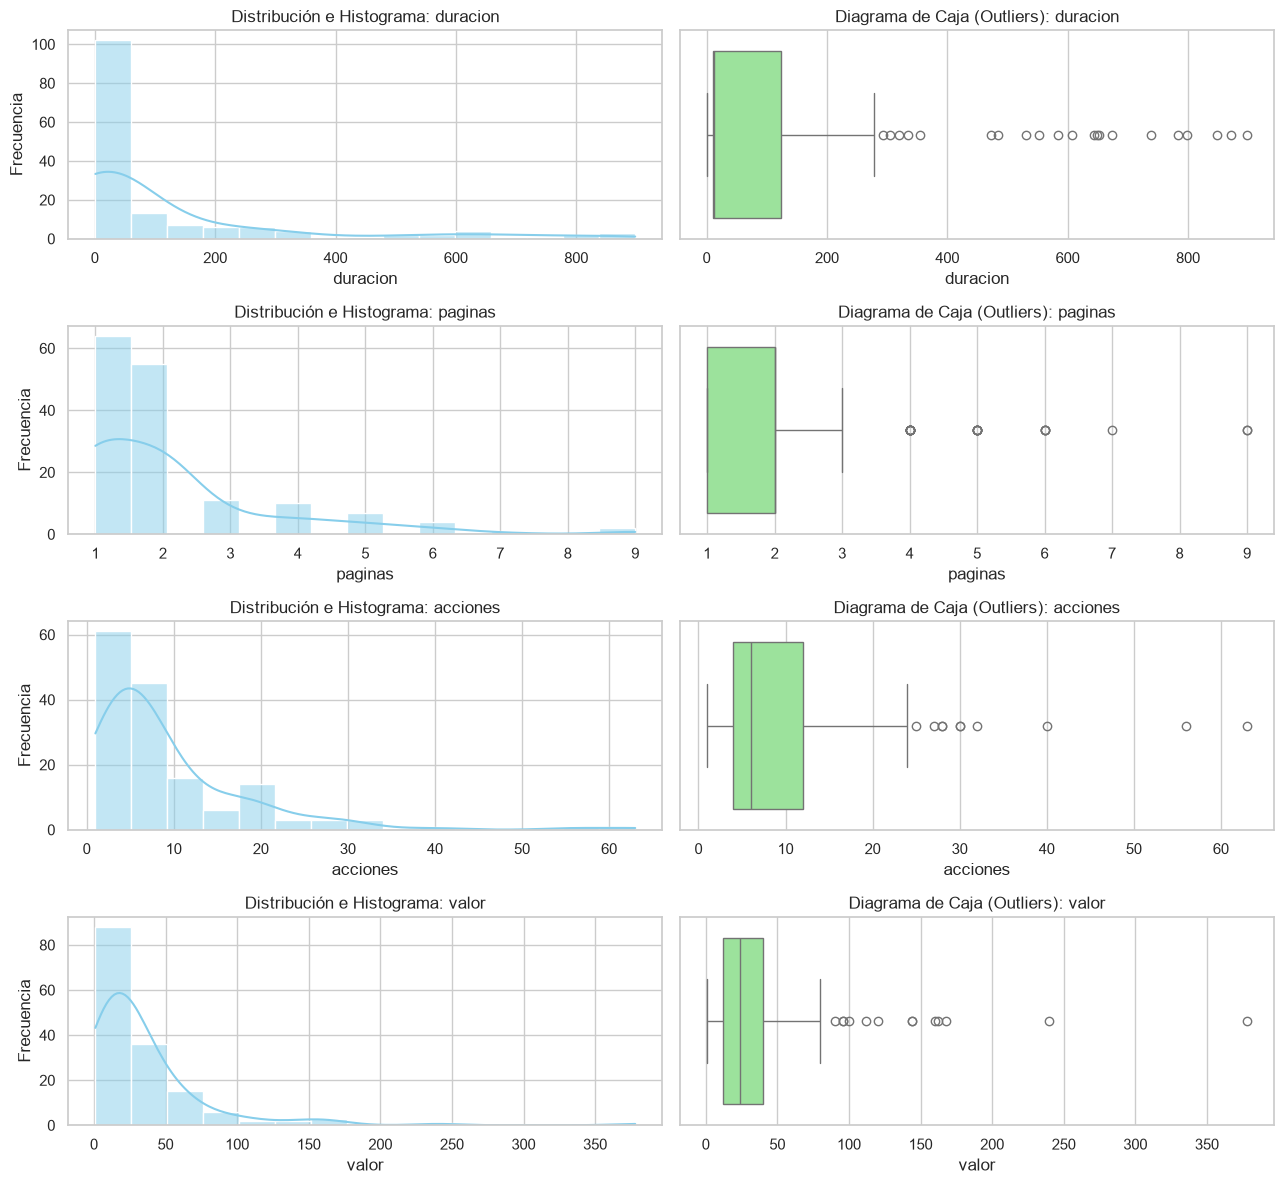

--- Detección Numérica de Outliers (Regla del 1.5 * IQR) ---
• Variable 'duracion': 21 registros atípicos (13.6% del total).
• Variable 'paginas': 24 registros atípicos (15.6% del total).
• Variable 'acciones': 10 registros atípicos (6.5% del total).
• Variable 'valor': 13 registros atípicos (8.4% del total).


In [89]:
# Visualización combinada: Histograma (Distribución) + Boxplot (Outliers)
fig, axes = plt.subplots(4, 2, figsize=(13, 12))

for i, col in enumerate(variables_predictoras):
    # Histograma con KDE
    sns.histplot(
        df[col], kde=True, ax=axes[i, 0], color="skyblue", bins=15
    )
    axes[i, 0].set_title(f"Distribución e Histograma: {col}")
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel("Frecuencia")

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i, 1], color="lightgreen")
    axes[i, 1].set_title(f"Diagrama de Caja (Outliers): {col}")
    axes[i, 1].set_xlabel(col)

plt.tight_layout()
plt.show()

# Cuantificación numérica de outliers mediante la regla 1.5 * IQR de Tukey
print("--- Detección Numérica de Outliers (Regla del 1.5 * IQR) ---")
for col in variables_predictoras:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = df[(df[col] < (q1 - 1.5 * iqr)) | (df[col] > (q3 + 1.5 * iqr))]
    porcentaje = (len(outliers) / len(df)) * 100
    print(
        f"• Variable '{col}': {len(outliers)} registros atípicos ({porcentaje:.1f}% del total).")

**Interpretación de la Distribución y Decisión Metodológica:**

1. **Diagnóstico de Asimetría (Histogramas):**
   * Las cuatro variables predictoras (`duracion`, `paginas`, `acciones`, `valor`) muestran una marcada **asimetría positiva (sesgo a la derecha)**. La mayoría de los usuarios registran interacciones moderadas, mientras que un grupo reducido genera valores muy elevados.
2. **Conservación de Registros Atípicos:**
   * La regla de Tukey detecta un número significativo de observaciones en la cola superior (por ejemplo, 15.6% en `paginas` y 13.6% en `duracion`). Aplicar el método de Tukey para eliminar estas filas descartaría más del **27.3% del dataset total** (42 observaciones de 154), deformando la representatividad de la muestra y reduciendo en exceso los datos de las clases minoritarias.
3. **Tratamiento en Preprocesamiento:**
   * Dado que corresponden a comportamientos de navegación reales y no a errores de carga, se conservan los datos y se mitiga el efecto de la escala y la asimetría aplicando **estandarización de características (`StandardScaler`)** antes de alimentar la Regresión Logística.

## Selección de Variables y División del Dataset

Para garantizar una evaluación justa y **evitar fuga de información (Data Leakage)**:
1. Dividimos los datos en **80% Entrenamiento** y **20% Prueba**.
2. Aplicamos **Estratificación (`stratify=y`)**: Mantiene exactamente la misma proporción de desbalance de clases en ambos conjuntos.

In [90]:
X = df[variables_predictoras]
y = df["clase"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Muestras de entrenamiento: {X_train.shape[0]}")
print(f"Muestras de prueba: {X_test.shape[0]}")

Muestras de entrenamiento: 123
Muestras de prueba: 31


## Escalado de Características (Feature Scaling)

Ajustamos el `StandardScaler` **únicamente con los datos de entrenamiento** (`fit_transform`) y aplicamos la transformación al conjunto de prueba (`transform`) para prevenir *Data Leakage*.

In [91]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Tratamiento del Desbalance y Entrenamiento del Modelo

### Ponderación de Pesos de Clase (`class_weight='balanced'`)

Para corregir el sesgo provocado por la mayor proporción de la Clase 0, incorporamos el parámetro `class_weight='balanced'`.

**Mecanismo:** 
Ajusta los pesos de la función de pérdida de manera inversamente proporcional a las frecuencias de cada clase en el conjunto de entrenamiento:
$$W_j = \frac{N}{K \times N_j}$$

Donde $N$ es el total de observaciones, $K$ el número de clases y $N_j$ la cantidad de muestras de la clase $j$. Penaliza con mayor severidad los errores cometidos en las clases minoritarias (1 y 2), asegurando que el algoritmo las atienda de forma equitativa.

In [92]:
# Instanciamos el modelo incorporando el tratamiento explícito de desbalance
model = LogisticRegression(random_state=42, class_weight="balanced")

# Entrenamiento sobre datos escalados
model.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default

## Evaluación del Modelo de Clasificación

Generamos las predicciones sobre el conjunto de prueba ($X_{test}$) y evaluamos el rendimiento mediante métricas estándar.

In [93]:
y_pred = model.predict(X_test_scaled)

print("--- REPORTE DE CLASIFICACIÓN DETALLADO ---")
print(classification_report(y_test, y_pred))
print(f"Accuracy General del Modelo: {accuracy_score(y_test, y_pred):.4f}")

--- REPORTE DE CLASIFICACIÓN DETALLADO ---
              precision    recall  f1-score   support

           0       1.00      0.47      0.64        17
           1       0.88      0.88      0.88         8
           2       0.40      1.00      0.57         6

    accuracy                           0.68        31
   macro avg       0.76      0.78      0.70        31
weighted avg       0.85      0.68      0.69        31

Accuracy General del Modelo: 0.6774


### Visualización de la Matriz de Confusión

Observamos la distribución de aciertos y errores de clasificación entre las distintas clases.

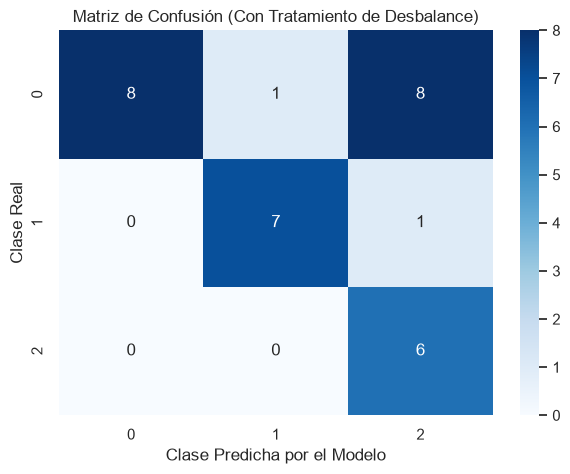

In [94]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_,
)
plt.title("Matriz de Confusión (Con Tratamiento de Desbalance)")
plt.xlabel("Clase Predicha por el Modelo")
plt.ylabel("Clase Real")
plt.show()

### Interpretación Detallada de la Matriz de Confusión y Métricas del Dataset


#### Definición Conceptual de las Métricas de Evaluación

1. **Accuracy (Exactitud General - 67.7%):**
   * **¿Qué es?**: Mide la proporción total de predicciones correctas sobre el total de casos.
   * **En este dataset**: De las 31 observaciones de prueba, el modelo acertó en 21 ($8 + 7 + 6 = 21$), logrando un $21 / 31 \approx 67.7\%$.

2. **Recall (Sensibilidad o Tasa de Detección):**
   * **¿Qué es?**: Responde a la pregunta: *De todos los usuarios que REALMENTE pertenecen a una clase, ¿qué porcentaje logró capturar el modelo?*
   * **En este dataset**: Un Recall del 100% en la Clase 2 significa que detectó a los 6 usuarios reales sin dejar escapar a ninguno (cero Falsos Negativos). En cambio, un Recall del 47% en la Clase 0 significa que solo atrapó a 8 de los 17 usuarios reales.

3. **Precisión (Precision):**
   * **¿Qué es?**: Responde a la pregunta: *Cuando el modelo predice que un usuario es de cierta clase, ¿qué tan seguro es que realmente lo sea?*
   * **En este dataset**: Una Precisión del 40% en la Clase 2 indica que de 15 veces que predijo Clase 2, solo 6 eran reales y 9 fueron falsas alarmas (Falsos Positivos).

4. **F1-Score (Balance Armónico):**
   * **¿Qué es?**: Es la **media armónica entre Precisión y Recall** ($2 \times \frac{\text{Precisión} \times \text{Recall}}{\text{Precisión} + \text{Recall}}$). Penaliza los desequilibrios extremos y da una nota global de calidad para cada clase.

---

#### Desglose Número por Número de la Matriz

1. **Primera Fila — Usuarios que REALMENTE pertenecen a la Clase 0 (17 usuarios reales):**
   * **8 (Aciertos / Verdaderos Positivos de Clase 0):** El modelo predijo correctamente Clase 0 para 8 usuarios.
   * **1 (Error / Falso Positivo de Clase 1):** El modelo clasificó a 1 usuario de Clase 0 como si fuera de Clase 1.
   * **8 (Error / Falso Positivo de Clase 2):** El modelo clasificó a 8 usuarios de Clase 0 como si fueran de Clase 2.
   * *Diagnóstico:* Refleja la pérdida de sensibilidad en la clase mayoritaria ($\text{Recall} = 8/17 \approx 47\%$) provocada por el parámetro `class_weight='balanced'`.

2. **Segunda Fila — Usuarios que REALMENTE pertenecen a la Clase 1 (8 usuarios reales):**
   * **0:** Ningún usuario de Clase 1 fue confundido con Clase 0.
   * **7 (Aciertos / Verdaderos Positivos de Clase 1):** El modelo identificó correctamente a 7 usuarios.
   * **1 (Error / Falso Positivo de Clase 2):** Solamente 1 usuario de Clase 1 fue desviado a Clase 2.
   * *Diagnóstico:* Excelente desempeño ($\text{Recall} = 7/8 = 88\%$ y $\text{Precisión} = 7/8 = 88\%$, logrando un $\text{F1-Score} = 0.88$).

3. **Tercera Fila — Usuarios que REALMENTE pertenecen a la Clase 2 (6 usuarios reales):**
   * **0:** Ningún usuario de Clase 2 fue clasificado como Clase 0.
   * **0:** Ningún usuario de Clase 2 fue clasificado como Clase 1.
   * **6 (Aciertos / Verdaderos Positivos de Clase 2):** El modelo capturó a **los 6 usuarios reales** de la Clase 2.
   * *Diagnóstico:* Alcanza un **Recall perfecto ($6/6 = 100\%$)**. El costo de esta alta sensibilidad fue que la columna de la Clase 2 recibió 9 falsas alarmas (8 de Clase 0 + 1 de Clase 1), reduciendo su Precisión al 40% ($6 / 15$) y su $\text{F1-Score}$ al 57% ($0.57$).

## Análisis e Interpretación de Coeficientes (Inferencia de Negocio)

Calculamos la razón de probabilidades u **Odds Ratios** ($e^\beta$) para analizar el impacto directo de cada variable sobre las probabilidades de pertenecer a cada clase.

#### ¿Cómo se obtienen los Coeficientes y los Odds Ratios en el código?

1. **Extracción de Coeficientes ($\beta$):** A través del atributo `model.coef_` del modelo entrenado de `scikit-learn`, obtenemos los pesos matemáticos directos (los log-odds) que el algoritmo asignó a cada variable para cada clase.
2. **Cálculo de los Odds Ratios ($e^\beta$):** Para transformar esos coeficientes en una medida de probabilidad interpretable, aplicamos la función exponencial de NumPy (`np.exp(model.coef_)`), elevando la constante $e$ a la potencia de cada coeficiente. Esto nos permite analizar el impacto porcentual de cada variable sobre las probabilidades de pertenecer a la clase.

In [95]:
# Construcción del DataFrame de Coeficientes y Odds Ratios
coef_df = pd.DataFrame(
    model.coef_, columns=variables_predictoras, index=[f"Clase {c}" for c in model.classes_]
)

odds_ratios = pd.DataFrame(
    np.exp(model.coef_),
    columns=variables_predictoras,
    index=[f"Clase {c} (Odds Ratio)" for c in model.classes_],
)

print("--- COEFICIENTES DEL MODELO (BETAS) ---")
display(coef_df.round(4))

print("\n--- ODDS RATIOS (exp(Beta)) ---")
display(odds_ratios.round(4))

--- COEFICIENTES DEL MODELO (BETAS) ---


,duracion,paginas,acciones,valor
Clase 0,-0.3810,-0.4824,1.3695,0.8692
Clase 1,0.1983,-0.2799,-0.7363,2.0806
Clase 2,0.1827,0.7623,-0.6333,-2.9498



--- ODDS RATIOS (exp(Beta)) ---


,duracion,paginas,acciones,valor
Clase 0 (Odds Ratio),0.6832,0.6173,3.9334,2.3849
Clase 1 (Odds Ratio),1.2194,0.7559,0.4789,8.0091
Clase 2 (Odds Ratio),1.2004,2.1431,0.5309,0.0524


### Observaciones sobre el Peso de las Variables Predictoras

A partir de los **Odds Ratios ($e^\beta$)** obtenidos tras estandarizar las variables predictoras (`duracion`, `paginas`, `acciones`, `valor`), analizamos la influencia marginal de cada predictor según la clase:

* **Acciones en Clase 0 ($\text{Odds Ratio} = 3.93$):** 
  Muestra el mayor peso e impacto para este perfil. Por cada incremento de 1 desviación estándar en la cantidad de acciones realizadas, las probabilidades (*Odds*) de pertenecer a la Clase 0 **aumentan un 293%** (casi se cuadruplican).

* **Valor Monetario en Clase 1 ($\text{Odds Ratio} = 8.01$):** 
  Presenta el impacto relativo más dominante de todo el modelo. Un incremento de 1 desviación estándar en el valor transaccionado **multiplica por 8 las probabilidades** de que el usuario corresponda a la Clase 1.

* **Páginas Navegadas en Clase 2 ($\text{Odds Ratio} = 2.14$):** 
  Muestra una influencia positiva relevante. Por cada incremento de 1 desviación estándar en el número de páginas visitadas, las probabilidades de pertenecer a la Clase 2 **aumentan un 114%** (más del doble).

* **Efecto Inverso del Valor en Clase 2 ($\text{Odds Ratio} = 0.05$):** 
  Representa una penalización severa. Un Odds Ratio menor a 1 implica que a mayor valor gastado, las probabilidades de pertenecer a la Clase 2 **caen un 95%**, confirmando que este perfil es casi exclusivamente no comprador.

---

**Conclusión:**
Dado que las variables fueron estandarizadas con `StandardScaler`, este desglose nos permite comparar directamente el poder discriminativo de cada predictor. 
La marcada diferencia en el peso de **`valor`** entre la Clase 1 ($8.01$) y la Clase 2 ($0.05$) demuestra que el monto transaccionado es la variable clave que separa al perfil comercialmente rentable del perfil puramente exploratorio.